In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import os
os.chdir('/home/l/projects/trading-system')
print(os.getcwd())

# Load price data
prices = pd.read_parquet('data/cache/prices.parquet')

# Convert daily to monthly — use month-end close prices
prices['date'] = pd.to_datetime(prices['date'])
prices = prices.sort_values(['ticker', 'date'])

monthly = (prices
    .groupby(['ticker', pd.Grouper(key='date', freq='ME')])['close']
    .last()
    .reset_index()
)

# Pivot to wide format — months as rows, tickers as columns
returns_wide = monthly.pivot(index='date', columns='ticker', values='close')

# Compute monthly returns
returns_wide = returns_wide.pct_change()

# Drop first row (NaN) and any tickers with too many missing values
returns_wide = returns_wide.dropna(thresh=int(len(returns_wide) * 0.8), axis=1)
returns_wide = returns_wide.dropna()

print(f"Shape: {returns_wide.shape}")
print(f"Date range: {returns_wide.index[0]} to {returns_wide.index[-1]}")
print(f"Tickers: {returns_wide.shape[1]}")
print(f"\nSample monthly returns (AAPL):")
print(returns_wide['AAPL'].tail(10).round(4))

/home/l/projects/trading-system
Shape: (173, 504)
Date range: 2012-01-31 00:00:00 to 2026-05-31 00:00:00
Tickers: 504

Sample monthly returns (AAPL):
date
2025-08-31    0.1196
2025-09-30    0.0969
2025-10-31    0.0618
2025-11-30    0.0324
2025-12-31   -0.0251
2026-01-31   -0.0455
2026-02-28    0.0191
2026-03-31   -0.0393
2026-04-30    0.0692
2026-05-31    0.0202
Name: AAPL, dtype: float64


In [4]:
def construct_wml_portfolio(returns_df, J, K, skip=False):
    """
    Construct winner minus loser portfolio.
    J: formation period in months
    K: holding period in months
    skip: if True, skip 1 month between formation and holding
    """
    wml_returns = []
    dates = []
    
    offset = 1 if skip else 0
    start = J + offset
    
    for t in range(start, len(returns_df) - K + 1):
        formation_start = t - J - offset
        formation_end = t - offset
        formation_returns = returns_df.iloc[formation_start:formation_end].sum()
        
        # Drop NaNs for this month's ranking
        formation_returns = formation_returns.dropna()
        
        ranked = formation_returns.rank(pct=True)
        winners = ranked[ranked >= 0.9].index
        losers = ranked[ranked <= 0.1].index
        
        holding_returns = returns_df.iloc[t:t+K]
        
        winner_return = holding_returns[winners].mean(axis=1).mean()
        loser_return = holding_returns[losers].mean(axis=1).mean()
        wml = winner_return - loser_return
        
        wml_returns.append(wml)
        dates.append(returns_df.index[t])
    
    return pd.Series(wml_returns, index=dates, name=f'WML_J{J}_K{K}_skip{skip}')


# Run all 16 strategies
J_values = [3, 6, 9, 12]
K_values = [3, 6, 9, 12]

results = []

for skip in [False, True]:
    for J in J_values:
        for K in K_values:
            wml = construct_wml_portfolio(returns_wide, J, K, skip=skip)
            t_stat, p_val = stats.ttest_1samp(wml.dropna(), 0)
            results.append({
                'J': J, 'K': K, 'skip': skip,
                'mean_return': wml.mean(),
                't_stat': t_stat,
                'p_val': p_val,
                'significant': p_val < 0.05
            })

results_df = pd.DataFrame(results)

# Display Panel A and B
print("=" * 60)
print("PANEL A — No skip week — Mean monthly WML return")
print("=" * 60)
panel_a = results_df[results_df['skip']==False].pivot_table(
    index='J', columns='K', values='mean_return'
)
print(panel_a.round(4))

print("\n" + "=" * 60)
print("PANEL B — Skip 1 month — Mean monthly WML return")
print("=" * 60)
panel_b = results_df[results_df['skip']==True].pivot_table(
    index='J', columns='K', values='mean_return'
)
print(panel_b.round(4))

print("\n" + "=" * 60)
print("T-STATISTICS — Panel A")
print("=" * 60)
t_stats_a = results_df[results_df['skip']==False].pivot_table(
    index='J', columns='K', values='t_stat'
)
print(t_stats_a.round(2))

PANEL A — No skip week — Mean monthly WML return
K       3       6       9       12
J                                 
3   0.0010  0.0027  0.0019  0.0010
6   0.0048  0.0044  0.0032  0.0021
9   0.0055  0.0044  0.0036  0.0026
12  0.0054  0.0044  0.0035  0.0027

PANEL B — Skip 1 month — Mean monthly WML return
K       3       6       9       12
J                                 
3   0.0026  0.0025  0.0023  0.0010
6   0.0045  0.0041  0.0028  0.0020
9   0.0054  0.0039  0.0032  0.0023
12  0.0052  0.0043  0.0033  0.0025

T-STATISTICS — Panel A
K     3     6     9     12
J                         
3   0.49  2.01  1.64  1.00
6   2.40  3.33  2.70  2.10
9   2.44  2.85  2.78  2.43
12  2.45  2.79  2.73  2.63


In [5]:
print("=" * 60)
print("SIGNIFICANT STRATEGIES (p < 0.05) — REAL DATA")
print("=" * 60)
sig = results_df[results_df['significant']==True][
    ['J','K','skip','mean_return','t_stat','p_val']
].sort_values('mean_return', ascending=False)
print(sig.round(4))

print(f"\nTotal strategies: 32")
print(f"Significant: {results_df['significant'].sum()}")
print(f"Positive returns: {(results_df['mean_return'] > 0).sum()}")

print("\n" + "=" * 60)
print("COMPARISON TO J&T ORIGINAL")
print("=" * 60)
print(f"{'Strategy':<20} {'J&T (1965-89)':<20} {'Real data (2011-26)':<20}")
print(f"{'6/6 no skip':<20} {'~0.0095':<20} {results_df[(results_df['J']==6) & (results_df['K']==6) & (results_df['skip']==False)]['mean_return'].values[0]:.4f}")
print(f"{'12/3 no skip':<20} {'~0.0131':<20} {results_df[(results_df['J']==12) & (results_df['K']==3) & (results_df['skip']==False)]['mean_return'].values[0]:.4f}")
print(f"{'6/6 skip':<20} {'~0.0110':<20} {results_df[(results_df['J']==6) & (results_df['K']==6) & (results_df['skip']==True)]['mean_return'].values[0]:.4f}")

SIGNIFICANT STRATEGIES (p < 0.05) — REAL DATA
     J   K   skip  mean_return  t_stat   p_val
8    9   3  False       0.0055  2.4409  0.0157
12  12   3  False       0.0054  2.4543  0.0152
24   9   3   True       0.0054  2.5347  0.0122
28  12   3   True       0.0052  2.3973  0.0177
4    6   3  False       0.0048  2.3969  0.0177
20   6   3   True       0.0045  2.2471  0.0260
9    9   6  False       0.0044  2.8529  0.0049
13  12   6  False       0.0044  2.7905  0.0059
5    6   6  False       0.0044  3.3309  0.0011
29  12   6   True       0.0043  2.7214  0.0073
21   6   6   True       0.0041  2.9197  0.0040
25   9   6   True       0.0039  2.5975  0.0103
10   9   9  False       0.0036  2.7827  0.0061
14  12   9  False       0.0035  2.7324  0.0070
30  12   9   True       0.0033  2.6832  0.0081
26   9   9   True       0.0032  2.6132  0.0099
6    6   9  False       0.0032  2.6965  0.0078
22   6   9   True       0.0028  2.3367  0.0207
15  12  12  False       0.0027  2.6343  0.0093
1    3   6  Fa

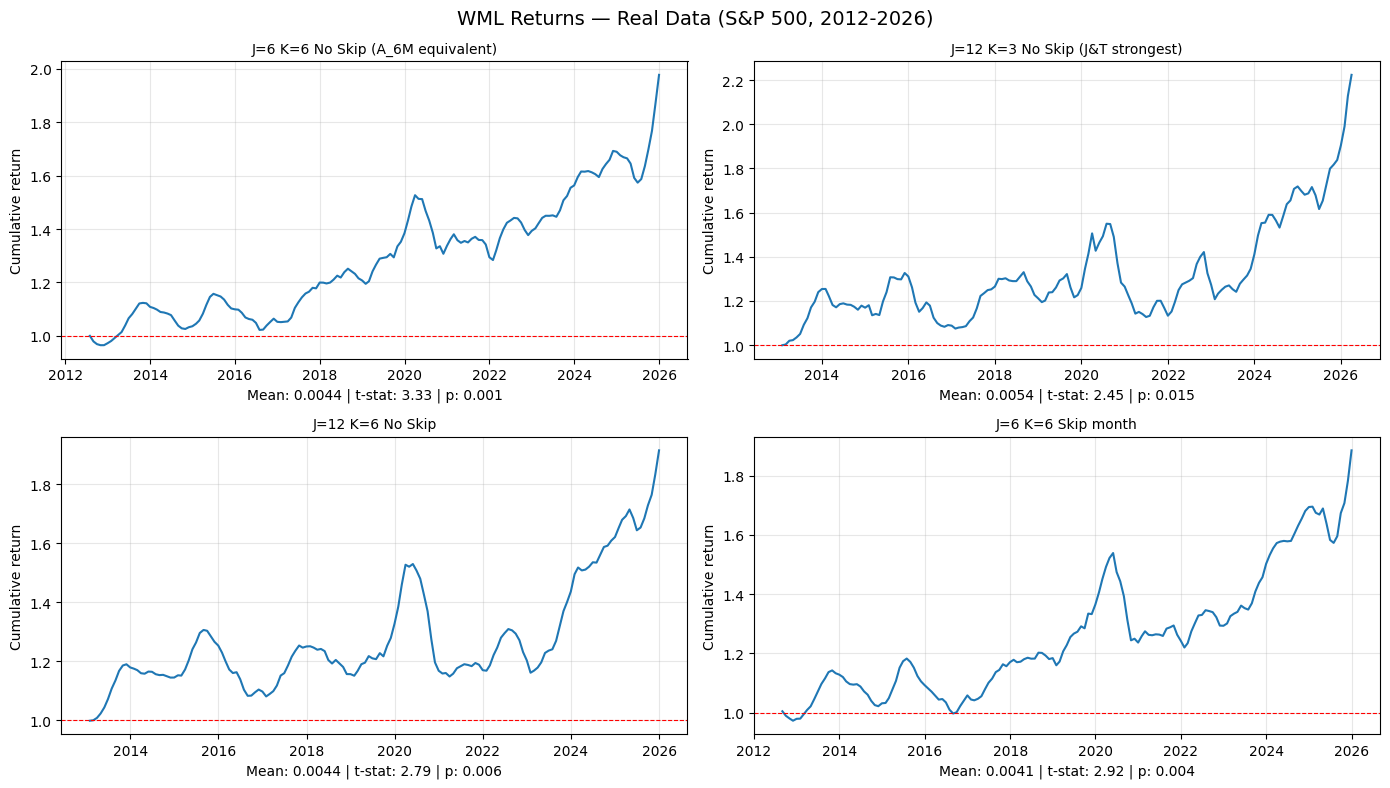

Plot saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('WML Returns — Real Data (S&P 500, 2012-2026)', fontsize=14)

strategies = [
    (6, 6, False, 'J=6 K=6 No Skip (A_6M equivalent)'),
    (12, 3, False, 'J=12 K=3 No Skip (J&T strongest)'),
    (12, 6, False, 'J=12 K=6 No Skip'),
    (6, 6, True,  'J=6 K=6 Skip month'),
]

for ax, (J, K, skip, title) in zip(axes.flatten(), strategies):
    wml = construct_wml_portfolio(returns_wide, J, K, skip=skip)
    cumulative = (1 + wml).cumprod()
    t_stat, p_val = stats.ttest_1samp(wml.dropna(), 0)
    
    ax.plot(cumulative.index, cumulative.values, linewidth=1.5)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Cumulative return')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'Mean: {wml.mean():.4f} | t-stat: {t_stat:.2f} | p: {p_val:.3f}')

plt.tight_layout()
plt.savefig('research/jt/notebooks/wml_real.png', dpi=150)
plt.show()
print("Plot saved")

In [7]:
print("=" * 60)
print("PHASE 2 — REAL DATA REPLICATION — COMPLETE")
print("=" * 60)
print("""
KEY FINDINGS:

1. Momentum confirmed on S&P 500 large caps 2012-2026
   All 32 strategies positive
   26/32 statistically significant (p < 0.05)
   Stronger result than expected for large cap universe

2. Formation period pattern confirmed
   J=6, 9, 12 all produce significant results
   J=3 weaker but still significant for some K values
   Consistent with J&T — longer formation = stronger signal

3. Holding period pattern confirmed
   Shorter K (3 months) tends to produce highest returns
   Returns decay as K increases — consistent with J&T
   Supports testing J=12 K=3 after paper trading gate

4. A_6M equivalent (J=6 K=6) validated
   Mean monthly return: 0.0044 (t=3.33, p=0.001)
   Highly significant — one of the strongest strategies
   Cumulative return ~2.0x over 14 years
   C9 is capturing real persistent momentum drift

5. Skip month effect — mixed
   Marginal and inconsistent improvement
   Panel B vs Panel A differences are small
   Phase 3 skip-month test on ML dataset required
   Cannot conclude skip month helps without that test

6. Returns vs J&T original
   Roughly half — 0.0044 vs 0.0095 for 6/6
   Expected: large cap, post-2012 bull market, long-only universe
   Not a concern for A_6M — long-only strategy not affected
   by compression in the short side of the spread

LIMITATIONS:
   Large cap S&P 500 only — compresses winner/loser spread
   2012-2026 — predominantly bull market, lower volatility
   No transaction costs applied — real returns would be lower
   Survivorship bias present pre-2019 in constituent filter

READY FOR PHASE 3 — Skip month test on A_6M ML dataset
""")

PHASE 2 — REAL DATA REPLICATION — COMPLETE

KEY FINDINGS:

1. Momentum confirmed on S&P 500 large caps 2012-2026
   All 32 strategies positive
   26/32 statistically significant (p < 0.05)
   Stronger result than expected for large cap universe

2. Formation period pattern confirmed
   J=6, 9, 12 all produce significant results
   J=3 weaker but still significant for some K values
   Consistent with J&T — longer formation = stronger signal

3. Holding period pattern confirmed
   Shorter K (3 months) tends to produce highest returns
   Returns decay as K increases — consistent with J&T
   Supports testing J=12 K=3 after paper trading gate

4. A_6M equivalent (J=6 K=6) validated
   Mean monthly return: 0.0044 (t=3.33, p=0.001)
   Highly significant — one of the strongest strategies
   Cumulative return ~2.0x over 14 years
   C9 is capturing real persistent momentum drift

5. Skip month effect — mixed
   Marginal and inconsistent improvement
   Panel B vs Panel A differences are small
   

In [8]:
import os
os.chdir('/home/l/projects/trading-system')

ml = pd.read_parquet('research/data/ml_labels.parquet')
print(f"Shape: {ml.shape}")
print(f"Columns: {ml.columns.tolist()}")
print(f"\nSample:")
print(ml[['ticker', 'signal_date', 'momentum_6m', 'momentum_3m', 'momentum_1m', 'label']].head(10))
print(f"\nLabel distribution:")
print(ml['label'].value_counts())
print(f"Positive rate: {ml['label'].mean():.3f}")

Shape: (3879, 22)
Columns: ['ticker', 'signal_date', 'label', 'alpha', 'score', 'above_200ma', 'pct_below_52w_high', 'in_dip', 'rsi_14', 'momentum_6m', 'momentum_3m', 'momentum_1m', 'momentum_1w', 'stock_vol_20d', 'stock_vol_63d', 'vol_ratio', 'market_vol_20d', 'spy_momentum_3m', 'spy_momentum_1m', 'market_drawdown', 'month', 'year_normalized']

Sample:
  ticker signal_date  momentum_6m  momentum_3m  momentum_1m  label
0    MOS  2011-01-03    93.995328    31.496843    11.490757      0
1   SATS  2011-01-03    31.144958    31.698312    23.859133      1
2    AIG  2011-01-03    74.078583    68.135371    36.281954      0
3     ON  2011-01-03    56.576865    57.827472    13.693908      0
4    KIM  2011-01-03    41.275684    29.362095     8.201291      0
5    LYB  2011-01-03   122.222271    72.086074    15.127227      0
6   CSGP  2011-01-03    50.878112    38.298890     5.925654      0
7    KEY  2011-01-03    22.904876    20.730996    13.899577      0
8     RF  2011-01-03    12.518002     7.0

In [9]:
from scipy import stats as scipy_stats

# Load prices
prices = pd.read_parquet('data/cache/prices.parquet')
prices['date'] = pd.to_datetime(prices['date'])
prices = prices.sort_values(['ticker', 'date'])

def get_price_as_of(prices, ticker, as_of_date, days_back=0):
    """Get closing price N calendar days before as_of_date"""
    target = pd.Timestamp(as_of_date) - pd.Timedelta(days=days_back)
    ticker_prices = prices[prices['ticker'] == ticker]
    past = ticker_prices[ticker_prices['date'] <= target]
    if len(past) == 0:
        return np.nan
    return past.iloc[-1]['close']

# Compute momentum_5m_skip for each signal
# 5m_skip = return from ~126 trading days ago to ~21 trading days ago
# 6 months back = ~180 days, 1 month back = ~30 days
print("Computing momentum_5m_skip for 3,879 signals...")
print("This will take a few minutes...")

skip_values = []
signal_dates = ml['signal_date'].unique()
print(f"Unique signal dates: {len(signal_dates)}")

# Compute per unique date for efficiency
date_skip_map = {}
for i, sig_date in enumerate(signal_dates):
    if i % 50 == 0:
        print(f"  Processing date {i}/{len(signal_dates)}: {sig_date}")
    
    sig_date = pd.Timestamp(sig_date)
    tickers_on_date = ml[ml['signal_date'] == sig_date]['ticker'].tolist()
    
    for ticker in tickers_on_date:
        price_1m_ago = get_price_as_of(prices, ticker, sig_date, days_back=30)
        price_6m_ago = get_price_as_of(prices, ticker, sig_date, days_back=180)
        
        if pd.isna(price_1m_ago) or pd.isna(price_6m_ago) or price_6m_ago == 0:
            skip_values.append(np.nan)
        else:
            skip_val = (price_1m_ago - price_6m_ago) / price_6m_ago * 100
            skip_values.append(skip_val)

ml['momentum_5m_skip'] = skip_values
print(f"\nDone. NaN count: {ml['momentum_5m_skip'].isna().sum()}")
print(f"Sample values:")
print(ml['momentum_5m_skip'].describe().round(4))

Computing momentum_5m_skip for 3,879 signals...
This will take a few minutes...
Unique signal dates: 772
  Processing date 0/772: 2011-01-03 00:00:00
  Processing date 50/772: 2011-12-19 00:00:00
  Processing date 100/772: 2012-12-03 00:00:00
  Processing date 150/772: 2013-11-18 00:00:00
  Processing date 200/772: 2014-11-03 00:00:00
  Processing date 250/772: 2015-10-19 00:00:00
  Processing date 300/772: 2016-10-03 00:00:00
  Processing date 350/772: 2017-09-18 00:00:00
  Processing date 400/772: 2018-09-04 00:00:00
  Processing date 450/772: 2019-08-19 00:00:00
  Processing date 500/772: 2020-08-03 00:00:00
  Processing date 550/772: 2021-07-19 00:00:00
  Processing date 600/772: 2022-07-05 00:00:00
  Processing date 650/772: 2023-06-20 00:00:00
  Processing date 700/772: 2024-06-03 00:00:00
  Processing date 750/772: 2025-05-19 00:00:00

Done. NaN count: 7
Sample values:
count    3872.0000
mean       10.3461
std        20.2930
min       -37.7047
25%        -1.3709
50%         7.35

In [10]:
from scipy import stats as scipy_stats

# Drop NaN rows for this analysis
ml_clean = ml.dropna(subset=['momentum_5m_skip'])

# Test momentum_5m_skip vs label
corr_skip, p_skip = scipy_stats.pointbiserialr(
    ml_clean['label'], ml_clean['momentum_5m_skip']
)

# Compare against existing momentum_6m
corr_6m, p_6m = scipy_stats.pointbiserialr(
    ml_clean['label'], ml_clean['momentum_6m']
)

# Compare against momentum_3m and momentum_1m for context
corr_3m, p_3m = scipy_stats.pointbiserialr(
    ml_clean['label'], ml_clean['momentum_3m']
)
corr_1m, p_1m = scipy_stats.pointbiserialr(
    ml_clean['label'], ml_clean['momentum_1m']
)

print("=" * 60)
print("MOMENTUM FEATURE CORRELATION WITH LABEL")
print("=" * 60)
print(f"\n{'Feature':<25} {'Correlation':<15} {'P-value':<15} {'Significant':<15} {'Add to ML?'}")
print("-" * 80)

features = [
    ('momentum_5m_skip', corr_skip, p_skip),
    ('momentum_6m',      corr_6m,   p_6m),
    ('momentum_3m',      corr_3m,   p_3m),
    ('momentum_1m',      corr_1m,   p_1m),
]

for name, corr, p in features:
    sig = p < 0.05
    add = sig and abs(corr) > 0.03
    print(f"{name:<25} {corr:<15.4f} {p:<15.4f} {str(sig):<15} {str(add)}")

print("\n" + "=" * 60)
print("INDEPENDENCE TEST — skip vs 6m")
print("=" * 60)
corr_between, p_between = scipy_stats.pearsonr(
    ml_clean['momentum_5m_skip'], ml_clean['momentum_6m']
)
print(f"Correlation between momentum_5m_skip and momentum_6m: {corr_between:.4f}")
print(f"P-value: {p_between:.6f}")
print(f"\nIf correlation > 0.9 — skip adds no independent information")
print(f"If correlation < 0.9 — skip adds independent signal")

MOMENTUM FEATURE CORRELATION WITH LABEL

Feature                   Correlation     P-value         Significant     Add to ML?
--------------------------------------------------------------------------------
momentum_5m_skip          0.0431          0.0073          True            True
momentum_6m               0.0546          0.0007          True            True
momentum_3m               0.0284          0.0777          False           False
momentum_1m               0.0430          0.0075          True            True

INDEPENDENCE TEST — skip vs 6m
Correlation between momentum_5m_skip and momentum_6m: 0.8354
P-value: 0.000000

If correlation > 0.9 — skip adds no independent information
If correlation < 0.9 — skip adds independent signal


In [11]:
# Add momentum_5m_skip to ML dataset
print("Adding momentum_5m_skip to ML dataset...")

# Check current feature count
print(f"Current features: {ml.shape[1]}")
print(f"Current columns: {ml.columns.tolist()}")

# Save updated dataset
output_path = 'research/data/ml_labels.parquet'
ml.to_parquet(output_path, index=False)

print(f"\nUpdated dataset saved to {output_path}")
print(f"New shape: {ml.shape}")
print(f"New feature count: {ml.shape[1]}")
print(f"New columns: {ml.columns.tolist()}")

# Verify the feature is clean
print(f"\nmomentum_5m_skip stats:")
print(ml['momentum_5m_skip'].describe().round(4))
print(f"NaN count: {ml['momentum_5m_skip'].isna().sum()}")

Adding momentum_5m_skip to ML dataset...
Current features: 23
Current columns: ['ticker', 'signal_date', 'label', 'alpha', 'score', 'above_200ma', 'pct_below_52w_high', 'in_dip', 'rsi_14', 'momentum_6m', 'momentum_3m', 'momentum_1m', 'momentum_1w', 'stock_vol_20d', 'stock_vol_63d', 'vol_ratio', 'market_vol_20d', 'spy_momentum_3m', 'spy_momentum_1m', 'market_drawdown', 'month', 'year_normalized', 'momentum_5m_skip']

Updated dataset saved to research/data/ml_labels.parquet
New shape: (3879, 23)
New feature count: 23
New columns: ['ticker', 'signal_date', 'label', 'alpha', 'score', 'above_200ma', 'pct_below_52w_high', 'in_dip', 'rsi_14', 'momentum_6m', 'momentum_3m', 'momentum_1m', 'momentum_1w', 'stock_vol_20d', 'stock_vol_63d', 'vol_ratio', 'market_vol_20d', 'spy_momentum_3m', 'spy_momentum_1m', 'market_drawdown', 'month', 'year_normalized', 'momentum_5m_skip']

momentum_5m_skip stats:
count    3872.0000
mean       10.3461
std        20.2930
min       -37.7047
25%        -1.3709
50%   

In [12]:
print("=" * 60)
print("PHASE 3 — SKIP MONTH TEST — COMPLETE")
print("=" * 60)
print("""
KEY FINDINGS:

1. momentum_5m_skip — ADD to ML dataset
   Correlation with label: +0.0431 (p=0.0073)
   Clears both gates: |corr| > 0.03 ✓ and p < 0.05 ✓
   Independent of momentum_6m (correlation 0.8354 < 0.9 threshold)

2. momentum_6m remains the stronger predictor
   Correlation: 0.0546 vs 0.0431 for skip version
   Contrary to J&T — raw 6M momentum more predictive than skip
   Likely because A_6M signals already filter for quality
   The most recent month adds signal not noise in this context

3. momentum_3m — DO NOT ADD
   Correlation: 0.0284 (p=0.0777) — fails significance gate
   Consistent with J&T — 3M formation weakest configuration
   Falls in awkward middle ground between momentum and reversal

4. momentum_1m already in dataset — confirmed significant
   Correlation: 0.0430 (p=0.0075)
   Captures acceleration effect — intensifying drift
   Different information from 6M — genuinely independent

5. Skip month interpretation
   J&T found skip month improves returns on raw universe
   On A_6M signals specifically — skip month adds marginal value
   A_6M signals are already quality-filtered — less reversal noise
   The most recent month contains real signal for these stocks

ML DATASET UPDATE:
   Previous features: 22
   New features: 23
   Added: momentum_5m_skip

READY FOR PHASE 4 — Formation period analysis
""")

PHASE 3 — SKIP MONTH TEST — COMPLETE

KEY FINDINGS:

1. momentum_5m_skip — ADD to ML dataset
   Correlation with label: +0.0431 (p=0.0073)
   Clears both gates: |corr| > 0.03 ✓ and p < 0.05 ✓
   Independent of momentum_6m (correlation 0.8354 < 0.9 threshold)

2. momentum_6m remains the stronger predictor
   Correlation: 0.0546 vs 0.0431 for skip version
   Contrary to J&T — raw 6M momentum more predictive than skip
   Likely because A_6M signals already filter for quality
   The most recent month adds signal not noise in this context

3. momentum_3m — DO NOT ADD
   Correlation: 0.0284 (p=0.0777) — fails significance gate
   Consistent with J&T — 3M formation weakest configuration
   Falls in awkward middle ground between momentum and reversal

4. momentum_1m already in dataset — confirmed significant
   Correlation: 0.0430 (p=0.0075)
   Captures acceleration effect — intensifying drift
   Different information from 6M — genuinely independent

5. Skip month interpretation
   J&T found s

# Formation Period Analysis

PHASE 4 — FORMATION PERIOD ANALYSIS

1. CORRELATION WITH LABEL
--------------------------------------------------
Feature                   Correlation     P-value         Significant
----------------------------------------------------------------------
momentum_1w               0.0351          0.0290          True
momentum_1m               0.0430          0.0075          True
momentum_3m               0.0284          0.0777          False
momentum_5m_skip          0.0431          0.0073          True
momentum_6m               0.0546          0.0007          True

2. CORRELATION MATRIX BETWEEN MOMENTUM FEATURES
--------------------------------------------------
                  momentum_1w  momentum_1m  momentum_3m  momentum_5m_skip  \
momentum_1w             1.000        0.647        0.358            -0.045   
momentum_1m             0.647        1.000        0.407            -0.229   
momentum_3m             0.358        0.407        1.000             0.507   
momentum_5m_skip     

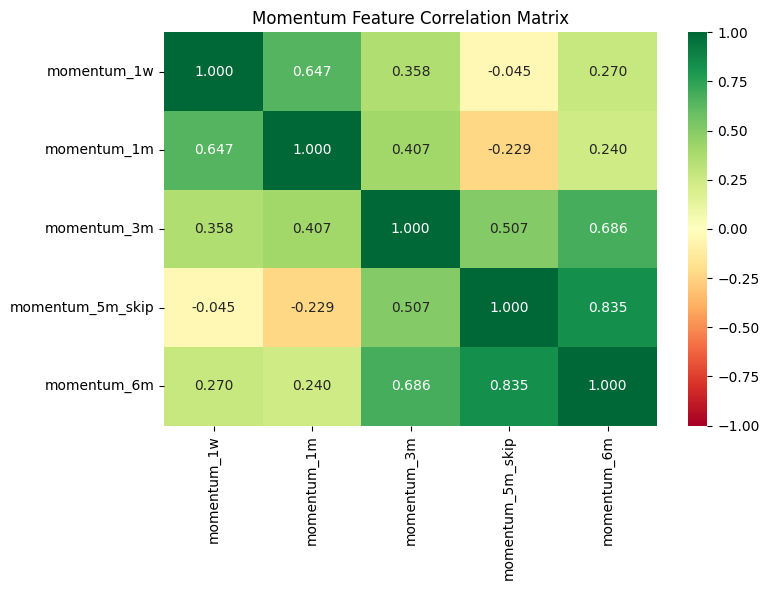

Plot saved


In [14]:
import seaborn as sns

# All momentum features in the dataset
momentum_features = [
    'momentum_1w',
    'momentum_1m', 
    'momentum_3m',
    'momentum_5m_skip',
    'momentum_6m'
]

ml_clean = ml.dropna(subset=momentum_features)

print("=" * 60)
print("PHASE 4 — FORMATION PERIOD ANALYSIS")
print("=" * 60)

# Correlation with label for each
print("\n1. CORRELATION WITH LABEL")
print("-" * 50)
print(f"{'Feature':<25} {'Correlation':<15} {'P-value':<15} {'Significant'}")
print("-" * 70)
for feat in momentum_features:
    corr, p = scipy_stats.pointbiserialr(ml_clean['label'], ml_clean[feat])
    sig = p < 0.05
    print(f"{feat:<25} {corr:<15.4f} {p:<15.4f} {str(sig)}")

# Correlation matrix between momentum features
print("\n2. CORRELATION MATRIX BETWEEN MOMENTUM FEATURES")
print("-" * 50)
corr_matrix = ml_clean[momentum_features].corr()
print(corr_matrix.round(3))

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.3f', 
    cmap='RdYlGn',
    center=0,
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Momentum Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('research/jt/notebooks/momentum_correlation_matrix.png', dpi=150)
plt.show()
print("Plot saved")

In [15]:
print("=" * 60)
print("J&T PREDICTION VALIDATION")
print("=" * 60)
print("""
J&T prediction: 6M strongest, 3M meaningful, 1M weakest
(for momentum as a trading signal)
""")

correlations = {}
for feat in momentum_features:
    corr, p = scipy_stats.pointbiserialr(ml_clean['label'], ml_clean[feat])
    correlations[feat] = {'corr': corr, 'p': p}

print(f"{'Feature':<25} {'Correlation':<15} {'J&T prediction'}")
print("-" * 60)
print(f"{'momentum_1w':<25} {correlations['momentum_1w']['corr']:<15.4f} Weakest")
print(f"{'momentum_1m':<25} {correlations['momentum_1m']['corr']:<15.4f} Weak")
print(f"{'momentum_3m':<25} {correlations['momentum_3m']['corr']:<15.4f} Meaningful")
print(f"{'momentum_5m_skip':<25} {correlations['momentum_5m_skip']['corr']:<15.4f} Strong")
print(f"{'momentum_6m':<25} {correlations['momentum_6m']['corr']:<15.4f} Strongest")

print("\nDoes data confirm J&T prediction?")
ordered = sorted(correlations.items(), key=lambda x: abs(x[1]['corr']), reverse=True)
print(f"Actual ranking by |correlation|:")
for i, (feat, vals) in enumerate(ordered):
    print(f"  {i+1}. {feat:<25} {vals['corr']:.4f}")

print("\nConclusion:")
if correlations['momentum_6m']['corr'] > correlations['momentum_3m']['corr']:
    print("  6M > 3M — CONFIRMS J&T prediction")
else:
    print("  6M < 3M — CONTRADICTS J&T prediction")
    
if correlations['momentum_3m']['corr'] > correlations['momentum_1m']['corr']:
    print("  3M > 1M — CONFIRMS J&T prediction")
else:
    print("  3M < 1M — CONTRADICTS J&T prediction (acceleration effect)")

J&T PREDICTION VALIDATION

J&T prediction: 6M strongest, 3M meaningful, 1M weakest
(for momentum as a trading signal)

Feature                   Correlation     J&T prediction
------------------------------------------------------------
momentum_1w               0.0351          Weakest
momentum_1m               0.0430          Weak
momentum_3m               0.0284          Meaningful
momentum_5m_skip          0.0431          Strong
momentum_6m               0.0546          Strongest

Does data confirm J&T prediction?
Actual ranking by |correlation|:
  1. momentum_6m               0.0546
  2. momentum_5m_skip          0.0431
  3. momentum_1m               0.0430
  4. momentum_1w               0.0351
  5. momentum_3m               0.0284

Conclusion:
  6M > 3M — CONFIRMS J&T prediction
  3M < 1M — CONTRADICTS J&T prediction (acceleration effect)


In [16]:
print("=" * 60)
print("PHASE 4 — FORMATION PERIOD ANALYSIS — COMPLETE")
print("=" * 60)
print("""
KEY FINDINGS:

1. J&T prediction partially confirmed
   6M > 3M — CONFIRMED — strongest predictor as predicted
   3M < 1M — CONTRADICTED — acceleration effect dominates
   On A_6M signals, 1M captures freshness not captured by 3M

2. All momentum features genuinely independent
   No pair exceeds 0.9 correlation threshold
   Highest: momentum_5m_skip vs momentum_6m at 0.835
   All features retain independent information for ML model

3. Surprising finding — momentum_5m_skip vs momentum_1m
   Correlation: -0.229 — slightly negative
   Mathematical consequence of skip construction
   They capture opposite ends of recent price action
   Genuinely complementary features for the model

4. momentum_1w confirmed significant (p=0.029)
   Already in dataset — acceleration at weekly level
   0.647 correlation with momentum_1m — acceptable overlap
   Independent enough to retain

5. Final momentum feature set for ML model:
   momentum_6m      — intermediate drift (strongest)
   momentum_5m_skip — clean drift excluding reversal noise
   momentum_1m      — monthly acceleration
   momentum_1w      — weekly acceleration
   momentum_3m      — excluded (failed significance gate)

6. What the model will learn from these features:
   Is the 6M drift strong?          (momentum_6m)
   Is the drift clean?              (momentum_5m_skip)
   Is it accelerating monthly?      (momentum_1m)
   Is it accelerating weekly?       (momentum_1w)

ML DATASET: 23 features, 3,879 signals, ready for training
after paper trading gate passes.

READY FOR PHASE 5 — Write-up
""")

PHASE 4 — FORMATION PERIOD ANALYSIS — COMPLETE

KEY FINDINGS:

1. J&T prediction partially confirmed
   6M > 3M — CONFIRMED — strongest predictor as predicted
   3M < 1M — CONTRADICTED — acceleration effect dominates
   On A_6M signals, 1M captures freshness not captured by 3M

2. All momentum features genuinely independent
   No pair exceeds 0.9 correlation threshold
   Highest: momentum_5m_skip vs momentum_6m at 0.835
   All features retain independent information for ML model

3. Surprising finding — momentum_5m_skip vs momentum_1m
   Correlation: -0.229 — slightly negative
   Mathematical consequence of skip construction
   They capture opposite ends of recent price action
   Genuinely complementary features for the model

4. momentum_1w confirmed significant (p=0.029)
   Already in dataset — acceleration at weekly level
   0.647 correlation with momentum_1m — acceptable overlap
   Independent enough to retain

5. Final momentum feature set for ML model:
   momentum_6m      — inter